In [1]:
# from numba import njit, prange
import numpy as np
import faiss

data = np.load(f"../data/save/train_test-0-0-0-0.npz")

x = np.array(data["x"], dtype=np.float32)
y = np.array(data["y"], dtype=np.float32)
w = np.array(data["w"], dtype=np.float32)
coor = np.array(data["coor"], dtype=np.int64)

print(x.shape, y.shape, w.shape, coor.shape)

(909278, 108) (909278,) (909278,) (909278, 27, 3)


In [2]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

In [3]:
b = x.copy()
min_number = 100
distances, indices = index.search(b, min_number)
name = data["name"]

var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)

mean_of_distances = np.max(distances, axis=1)
mean_of_distances[mean_of_distances < 0.0001] = -1
mean_of_distances[mean_of_distances > 0.0001] = 0
mean_of_distances = -mean_of_distances

argsort_ = np.argsort(mean_of_distances * var_y)[::-1][:100]

energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
distances = distances[argsort_]
name = name[indices[argsort_]]

In [9]:
# (sum_of_distances_reverse * var_y)[argsort_]
index_check = 23
print(
    np.sum(
        (x[indices[argsort_[index_check]]] - x[indices[argsort_[index_check]]][0]) ** 2,
        axis=1,
    )
)
print(np.max(distances[index_check]))
print(np.max(np.abs((energy[index_check] - energy[index_check][0]) * 627.509)))
print(name[index_check])

[0.00000000e+00 1.66875424e-07 1.92241757e-07 2.30661982e-07
 3.78418434e-07 4.33313971e-07 4.84684790e-07 5.91502101e-07
 1.39825067e-06 1.40556426e-06 1.97148711e-06 3.54565032e-06
 4.88663864e-06 5.60049557e-06 6.18808508e-06 6.25024404e-06
 7.09135111e-06 7.25919290e-06 7.39447114e-06 7.52632241e-06
 7.76661909e-06 8.10523761e-06 8.12998860e-06 8.37633343e-06
 8.42723603e-06 8.99575116e-06 8.99721636e-06 9.27468773e-06
 9.72985072e-06 9.75789862e-06 9.96184826e-06 1.01306205e-05
 1.01592032e-05 1.01971082e-05 1.04772444e-05 1.04977244e-05
 1.06576135e-05 1.07683190e-05 1.08317345e-05 1.10178662e-05
 1.12848684e-05 1.17974741e-05 1.20262230e-05 1.23001464e-05
 1.23523987e-05 1.27899457e-05 1.28014090e-05 1.29113769e-05
 1.30438148e-05 1.31527631e-05 1.33790863e-05 1.34701604e-05
 1.35318996e-05 1.35340697e-05 1.39617341e-05 1.40762349e-05
 1.43997659e-05 1.44610613e-05 1.47189494e-05 1.49854959e-05
 1.50241012e-05 1.53112142e-05 1.53838228e-05 1.55165035e-05
 1.58241601e-05 1.615365

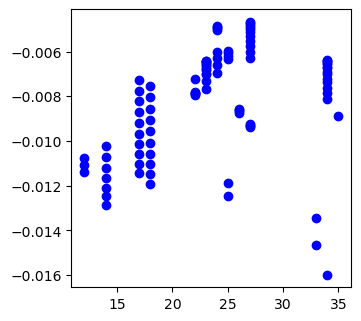

In [10]:
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72
name_energy_dict = {}

for i in range(min_number):
    name_energy_dict[name[index_check][i]] = energy[index_check][i] * 627.509


name_dict = {
    "methane": 0,
    "ethane": 1,
    "ethylene": 2,
    "acetylene": 3,
}

x_name_dict = {}
x_energy_dict = {}

for name_i, energy_i in name_energy_dict.items():
    x_ = name_dict[name_i.split("_")[0]] * 11 + float(name_i.split("_")[5])
    if x_ in x_name_dict:
        x_name_dict[x_].append([name_i, energy_i])
    else:
        x_name_dict[x_] = [[name_i, energy_i]]
    plt.scatter(x_, energy_i, c="b")

In [11]:
from pathlib import Path

Path("./plot").mkdir(parents=True, exist_ok=True)

for key_, value_ in x_name_dict.items():
    for j in value_:
        plt.scatter(float(j[0].split("_")[4]), j[1], c="r")
    plt.xticks(rotation=90)
    plt.xlabel(r"$\Delta$ x ($\AA$)")
    plt.ylabel("Energy (kcal/mol)")
    plt.xlim(-0.575, 0.575)
    plt.xticks(np.arange(-0.5, 0.6, 0.1))
    plt.savefig(f"./plot/{key_}.pdf", bbox_inches="tight")
    plt.savefig(f"./plot/{key_}.png", bbox_inches="tight", dpi=300)
    plt.close()
    print(key_, [i[0] for i in value_])

34.0 ['acetylene_cc-pVDZ_0-1_1_0.3000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.0500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.2500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.0000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.3500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.1000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.2000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.1500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_-0.0500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.4000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_-0.1000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.4500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_0.5000_1_28_155', 'acetylene_cc-pVDZ_0-1_1_-0.1500_1_28_155', 'acetylene_cc-pVDZ_0-1_1_-0.5000_1_27_154']
26.0 ['ethylene_cc-pVDZ_0-1_1_0.5000_4_27_4', 'ethylene_cc-pVDZ_0-1_1_0.4500_4_27_4', 'ethylene_cc-pVDZ_0-1_1_0.4000_4_27_4', 'ethylene_cc-pVDZ_0-1_1_0.3500_4_27_4']
22.0 ['ethylene_cc-pVDZ_0-1_1_0.4500_0_30_34', 'ethylene_cc-pVDZ_0-1_1_0.5000_0_30_34', 'ethylene_cc-pVDZ_0-1_1_0.4000_0_30_34', 'ethylene_cc-pVDZ_0-1_1_0.3500_0_30_34', 'ethylene

In [18]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72

f, axes = plt.subplots(1, 1)
axes = np.array(axes).reshape(1, 1)

begin_y = 0.125
end_y = 0.995
int_y = 0.0
begin_x = 0.175
end_x = 0.995
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-0.000003, 0.000033)
        axes[i, j].set_ylim(-0.022, 0.002)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, 0.00003])
            axes[i, j].set_xticklabels([0, 0.00003])
        # if j != 0:
        #     axes[i][j].set_yticks([])
        # else:
        #     axes[i][j].set_yticks([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticklabels([-0.03, -0.02, -0.01, 0])
        #     axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
        #     axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])

for j in range(indices.shape[1]):
    axes[0, 0].scatter(
        distances[index_check][j],
        energy[index_check][j] * 627.509,
        c=(color_dict[name[index_check][j].split("_")[0]],),
    )

axes[0, 0].scatter(
    distances[index_check][0],
    energy[index_check][0] * 627.509,
    c="r",
    marker="x",
)

for i, c in color_dict.items():
    axes[0, 0].scatter([-1], [-1], c=c, label=i)

plt.xlabel("Distance of cube")
plt.ylabel("$\Delta$ Energy (kcal/mol)")
plt.legend()

plt.savefig("sub_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig("sub_test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 361.111x361.111 with 0 Axes>

In [8]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([3, 3]) * 520 / 72

f, axes = plt.subplots(10, 10)
axes = axes.reshape(10, 10)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-0.00001, 0.00011)
        axes[i, j].set_ylim(-0.002, 0.022)
        # axes[i, j].set_ylim(-0.003, 0.033)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, 0.0001])
            axes[i, j].set_xticklabels([0, 0.0001])
        if j != 0:
            axes[i][j].set_yticks([])
        else:
            axes[i][j].set_yticks([0, 0.01, 0.02])
            axes[i][j].set_yticklabels([0, 0.01, 0.02])
            # axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
            # axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])


for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (10, 10))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distances[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=(color_dict[name[i][j].split("_")[0]],),
        )

    axes[axes_i, axes_j].text(
        0.01,
        1-0.01,
        f"{i}",
        transform=axes[axes_i, axes_j].transAxes,
        va="top",
    )
plt.savefig("test.pdf", dpi=300)
plt.clf()

<Figure size 2166.67x2166.67 with 0 Axes>

33.0 ['acetylene_cc-pVDZ_0-1_1_0.5000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.4500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.4000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.3500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.3000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.2500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.2000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.1500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.1000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.0500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_0.0000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.0500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.1000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.1500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.2000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.2500_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.3000_0_26_6', 'acetylene_cc-pVDZ_0-1_1_-0.3500_0_26_6']
16.0 ['ethane_cc-pVDZ_0-1_1_-0.3000_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.3500_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.2500_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.4000_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.2000_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.4500_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.5000_5_26_187', 'ethane_cc-pVDZ_0-1_1_-0.4500_5_26_187', 'ethane_cc-pVDZ_0-1_1_-0.1500_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.5000_5_25_59', 'ethane_cc-pVDZ_0-1_1_-0.4000_5_26_187', 'ethane_cc-pVDZ_0-1_1_-0.1000_5_25_59', 'ethane_cc-pVDZ_0-1_1_0.4000_5_24_147', 'ethane_cc-pVDZ_0-1_1_0.4500_5_24_147', 'ethane_cc-pVDZ_0-1_1_0.3500_5_24_147', 'ethane_cc-pVDZ_0-1_1_0.5000_5_24_147', 'ethane_cc-pVDZ_0-1_1_-0.3500_5_26_187', 'ethane_cc-pVDZ_0-1_1_0.3000_5_24_147', 'ethane_cc-pVDZ_0-1_1_0.2500_5_24_147']
26.0 ['ethylene_cc-pVDZ_0-1_1_0.2000_4_25_179', 'ethylene_cc-pVDZ_0-1_1_0.1500_4_25_179', 'ethylene_cc-pVDZ_0-1_1_0.2500_4_25_179', 'ethylene_cc-pVDZ_0-1_1_0.1000_4_25_179', 'ethylene_cc-pVDZ_0-1_1_0.3000_4_25_179', 'ethylene_cc-pVDZ_0-1_1_-0.3500_4_24_43', 'ethylene_cc-pVDZ_0-1_1_0.0500_4_25_179', 'ethylene_cc-pVDZ_0-1_1_-0.4000_4_24_43', 'ethylene_cc-pVDZ_0-1_1_-0.0500_4_24_155', 'ethylene_cc-pVDZ_0-1_1_0.0000_4_24_155', 'ethylene_cc-pVDZ_0-1_1_-0.3000_4_24_43', 'ethylene_cc-pVDZ_0-1_1_-0.1000_4_24_155', 'ethylene_cc-pVDZ_0-1_1_0.0500_4_24_155', 'ethylene_cc-pVDZ_0-1_1_-0.4500_4_24_43', 'ethylene_cc-pVDZ_0-1_1_-0.1500_4_24_155', 'ethylene_cc-pVDZ_0-1_1_0.0500_4_27_11', 'ethylene_cc-pVDZ_0-1_1_-0.2500_4_24_43']
17.0 ['ethane_cc-pVDZ_0-1_1_-0.0500_6_24_155', 'ethane_cc-pVDZ_0-1_1_-0.1000_6_24_155', 'ethane_cc-pVDZ_0-1_1_0.0000_6_24_155', 'ethane_cc-pVDZ_0-1_1_-0.1500_6_24_155', 'ethane_cc-pVDZ_0-1_1_0.0500_6_24_155', 'ethane_cc-pVDZ_0-1_1_-0.2000_6_24_155', 'ethane_cc-pVDZ_0-1_1_0.1000_6_24_155', 'ethane_cc-pVDZ_0-1_1_-0.2500_6_24_155', 'ethane_cc-pVDZ_0-1_1_0.1500_6_24_155', 'ethane_cc-pVDZ_0-1_1_0.3500_6_26_101', 'ethane_cc-pVDZ_0-1_1_0.4000_6_26_101']
23.0 ['ethylene_cc-pVDZ_0-1_1_-0.0500_1_27_146', 'ethylene_cc-pVDZ_0-1_1_-0.4500_1_26_6', 'ethylene_cc-pVDZ_0-1_1_-0.1000_1_27_146', 'ethylene_cc-pVDZ_0-1_1_-0.4000_1_26_6', 'ethylene_cc-pVDZ_0-1_1_0.0000_1_27_146', 'ethylene_cc-pVDZ_0-1_1_-0.5000_1_26_6', 'ethylene_cc-pVDZ_0-1_1_-0.1500_1_27_146', 'ethylene_cc-pVDZ_0-1_1_0.0500_1_27_146', 'ethylene_cc-pVDZ_0-1_1_-0.3500_1_26_6']
12.0 ['ethane_cc-pVDZ_0-1_1_-0.4500_1_26_6', 'ethane_cc-pVDZ_0-1_1_-0.4500_1_28_58', 'ethane_cc-pVDZ_0-1_1_-0.5000_1_28_58', 'ethane_cc-pVDZ_0-1_1_-0.5000_1_26_6', 'ethane_cc-pVDZ_0-1_1_-0.4000_1_26_6', 'ethane_cc-pVDZ_0-1_1_-0.4000_1_28_58', 'ethane_cc-pVDZ_0-1_1_-0.3500_1_26_6', 'ethane_cc-pVDZ_0-1_1_-0.3000_1_26_6']
25.0 ['ethylene_cc-pVDZ_0-1_1_-0.2000_3_28_162', 'ethylene_cc-pVDZ_0-1_1_-0.2500_3_28_162', 'ethylene_cc-pVDZ_0-1_1_-0.1500_3_28_162', 'ethylene_cc-pVDZ_0-1_1_-0.3000_3_28_162', 'ethylene_cc-pVDZ_0-1_1_-0.3500_3_28_162', 'ethylene_cc-pVDZ_0-1_1_-0.1000_3_28_162', 'ethylene_cc-pVDZ_0-1_1_0.0500_3_27_10', 'ethylene_cc-pVDZ_0-1_1_0.1000_3_27_10']
11.0 ['ethane_cc-pVDZ_0-1_1_-0.4500_0_29_34', 'ethane_cc-pVDZ_0-1_1_-0.5000_0_29_34', 'ethane_cc-pVDZ_0-1_1_-0.4000_0_29_34', 'ethane_cc-pVDZ_0-1_1_-0.3500_0_29_34']
13.0 ['ethane_cc-pVDZ_0-1_1_-0.1000_2_28_134', 'ethane_cc-pVDZ_0-1_1_-0.1500_2_28_134', 'ethane_cc-pVDZ_0-1_1_-0.2000_2_29_134', 'ethane_cc-pVDZ_0-1_1_-0.0500_2_28_134', 'ethane_cc-pVDZ_0-1_1_-0.1500_2_29_134', 'ethane_cc-pVDZ_0-1_1_-0.2500_2_29_134']